# GourmetAI Inc.
## **Food classifier**
***definizione di una rete neurale per computer vision al fine del riconoscimento automatico di cibo***

## Import moduli - Seed e selezione cpu/gpu
**sezione dedicata all'impostazione degli strumenti iniziali necessari per lo sviluppo del progetto. Gli strumenti comprendono anche la possibilità di riproducibilità del risultato e la selezione dell'hardware disponibile nella macchina. Si auspica l'utilizzo di gpu in quanto più efficienti nel calcolo vettoriale**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torchsummary import summary

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
import numpy as np
import os
import random

from sklearn.metrics import confusion_matrix
import seaborn as sns
import json

In [2]:
do_train = False

In [3]:
# Random seed for reproducibility
seed = 42

random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
torch.cuda.is_available()


False

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Connessione a googe drive


In [1]:
#from google.colab import drive
#drive.mount('/gdrive')
## inserire il path in cui si vuole operare e salvare i dati altrimenti
# %cd /gdrive/My\ Drive/

## Data augmentation

In [7]:
data_transforms = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),

            A.RandomRotate90(),
            A.HorizontalFlip(p=0.5),   
            A.Transpose(),

            ToTensorV2(),
        ])

data_to_tensor = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
            ToTensorV2(),
])

In [8]:
class Transforms:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']

## Input del dataset utile per il tuning della rete multiconnessa


In [9]:
trainset = torchvision.datasets.ImageFolder(root='dataset/train', transform=Transforms(data_transforms))

valset = torchvision.datasets.ImageFolder(root='dataset/val', transform=Transforms(data_to_tensor))

testset = torchvision.datasets.ImageFolder(root='dataset/test', transform=Transforms(data_to_tensor))

## Analisi del dataset

In [12]:
def back_to_image(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    return np.transpose(npimg, (1, 2, 0))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8199999].


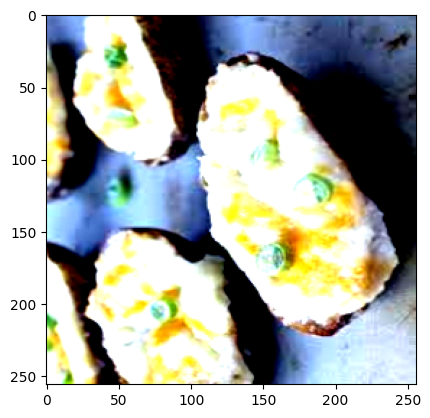

In [13]:
# test back_to_image(img)
image = back_to_image(trainset[0][0])
plt.imshow(image)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8199999].


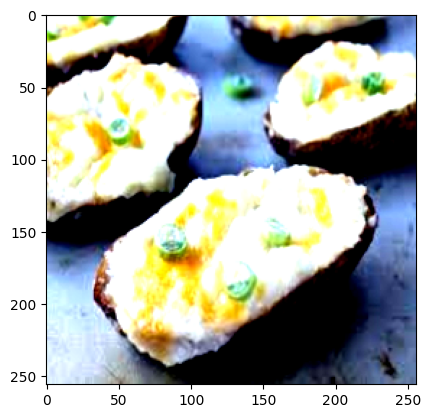

In [14]:
# test back_to_image(img)
image = back_to_image(trainset[0][0])
plt.imshow(image)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8199999].


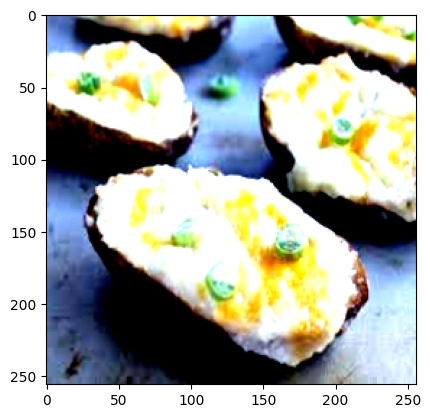

In [15]:
# test back_to_image(img)
image = back_to_image(trainset[0][0])
plt.imshow(image)
plt.show()

In [16]:
classes = trainset.classes
classes

['Baked Potato',
 'Crispy Chicken',
 'Donut',
 'Fries',
 'Hot Dog',
 'Sandwich',
 'Taco',
 'Taquito',
 'apple_pie',
 'cheesecake',
 'chicken_curry',
 'ice_cream',
 'omelette',
 'sushi']

In [17]:
len(classes)

14

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40222222..1.8199999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.8199999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.6979957].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5178571..1.6244541].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.40222222..1.8199999].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.558952..1.7938561].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5247024

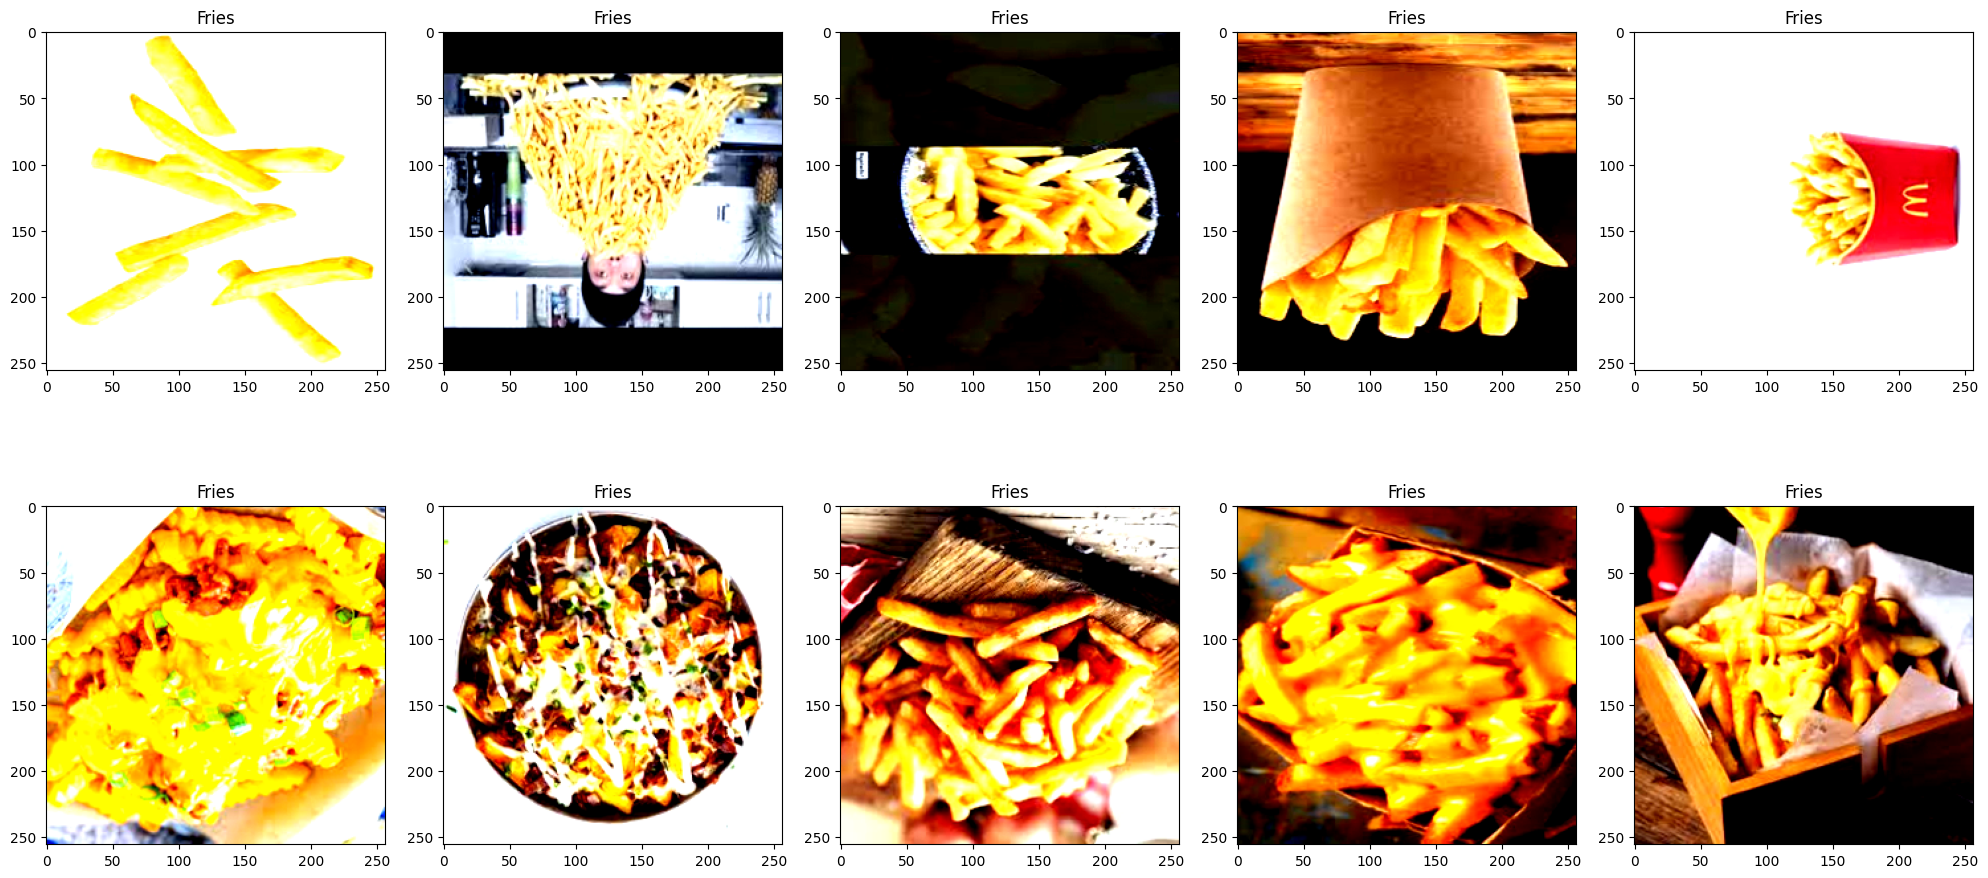

In [18]:
iteration = 200
num_row = 2
num_col = 5
fig, axes = plt.subplots(num_row, num_col, figsize=(10*num_row,2*num_col))
for i in range(num_row*num_col):
    ax = axes[i//num_col, i%num_col]
    ax.imshow(back_to_image(trainset[iteration * num_row * num_col + i][0]))
    ax.set_title('{}'.format(classes[int(trainset[iteration * num_row * num_col + i][1])]))
plt.tight_layout()
plt.show()
iteration += 1

## **Analisi della distribuzione delle classi nel dataset**


Distribuzione delle classi nel Training Set:


,class_id,count,class_name
0,0,640,Baked Potato
1,1,640,Crispy Chicken
2,2,640,Donut
3,3,640,Fries
4,4,640,Hot Dog
5,5,640,Sandwich
6,6,640,Taco
7,7,640,Taquito
8,8,640,apple_pie
9,9,640,cheesecake



Distribuzione delle classi nel Validation Set:


,class_id,count,class_name
0,0,160,Baked Potato
1,1,160,Crispy Chicken
2,2,160,Donut
3,3,160,Fries
4,4,160,Hot Dog
5,5,160,Sandwich
6,6,160,Taco
7,7,160,Taquito
8,8,160,apple_pie
9,9,160,cheesecake



Distribuzione delle classi nel Test Set:


,class_id,count,class_name
0,0,200,Baked Potato
1,1,200,Crispy Chicken
2,2,200,Donut
3,3,200,Fries
4,4,200,Hot Dog
5,5,200,Sandwich
6,6,200,Taco
7,7,200,Taquito
8,8,200,apple_pie
9,9,200,cheesecake


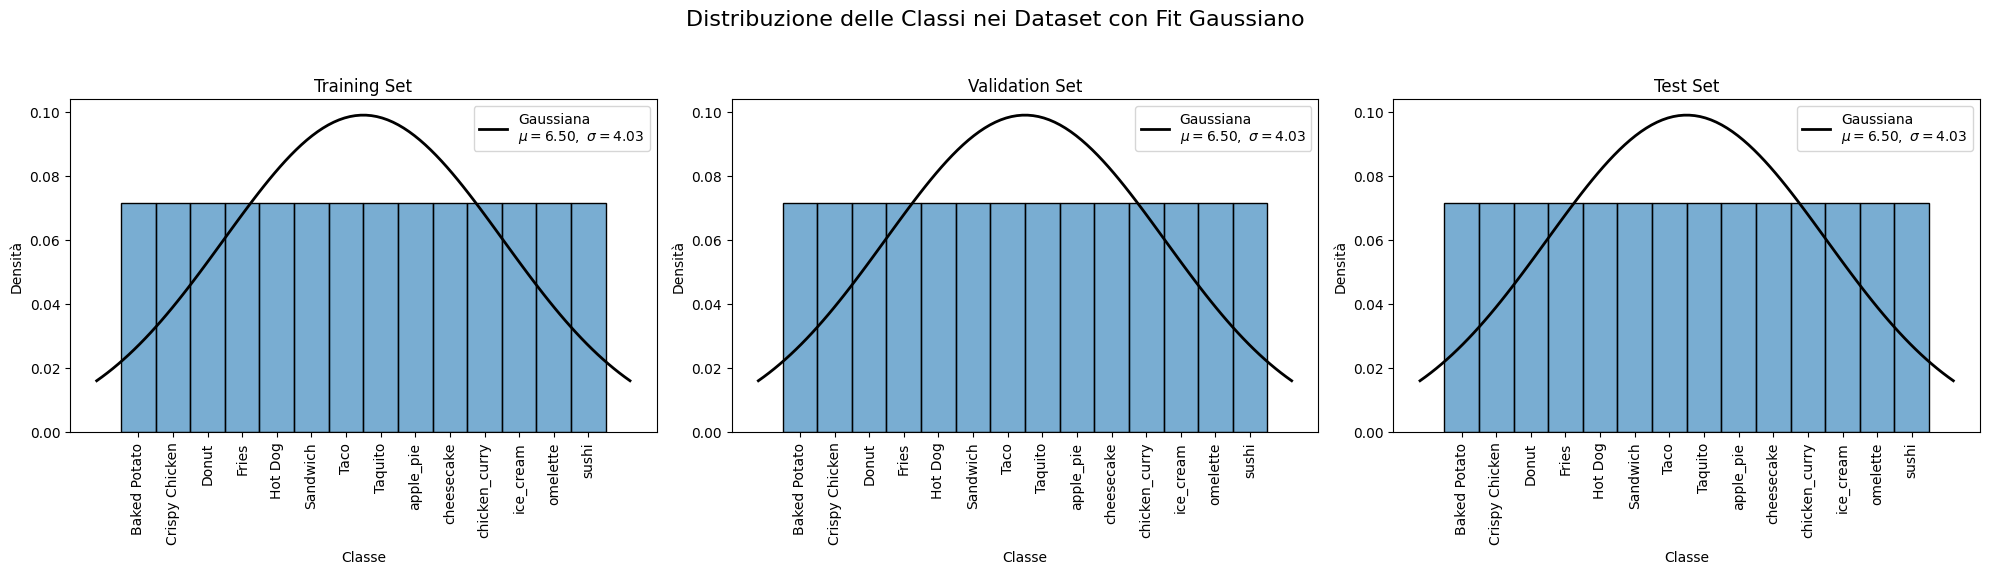

In [19]:
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Estrazione delle label nei dataset (memorizzate per calcolare i fit gaussiani)
train_labels = [label for _, label in trainset]
val_labels = [label for _, label in valset]
test_labels = [label for _, label in testset]

# Conteggio delle classi nel training set
train_class_counts = Counter(train_labels)
train_df = pd.DataFrame(train_class_counts.items(), columns=['class_id', 'count'])
train_df['class_name'] = train_df['class_id'].apply(lambda x: classes[x])

# Conteggio delle classi nel validation set
val_class_counts = Counter(val_labels)
val_df = pd.DataFrame(val_class_counts.items(), columns=['class_id', 'count'])
val_df['class_name'] = val_df['class_id'].apply(lambda x: classes[x])

# Conteggio delle classi nel test set
test_class_counts = Counter(test_labels)
test_df = pd.DataFrame(test_class_counts.items(), columns=['class_id', 'count'])
test_df['class_name'] = test_df['class_id'].apply(lambda x: classes[x])

print("Distribuzione delle classi nel Training Set:")
display(train_df.sort_values('class_id'))

print("\nDistribuzione delle classi nel Validation Set:")
display(val_df.sort_values('class_id'))

print("\nDistribuzione delle classi nel Test Set:")
display(test_df.sort_values('class_id'))

# 2. Creazione dei grafici (Istogrammi + Fit Gaussiano)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Distribuzione delle Classi nei Dataset con Fit Gaussiano', fontsize=16)

# Lista di tuple contenenti i dati necessari per ogni subplot
plot_data = [
    (train_labels, 'Training Set', axes[0]),
    (val_labels, 'Validation Set', axes[1]),
    (test_labels, 'Test Set', axes[2])
]

for labels, title, ax in plot_data:
    # A. Creazione dell'istogramma 
    # stat='density' è fondamentale per rendere l'istogramma compatibile con la scala della Gaussiana
    sns.histplot(labels, discrete=True, stat="density", color='#2077B4', alpha=0.6, ax=ax)
    
    # B. Calcolo dei parametri per la Gaussiana (Media e Deviazione Standard)
    mu, std = norm.fit(labels)
    
    # C. Generazione dei punti per tracciare la curva
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)
    
    # D. Sovrapposizione della curva Gaussiana al grafico
    ax.plot(x, p, 'k', linewidth=2, label=f'Gaussiana\n$\mu={mu:.2f},\ \sigma={std:.2f}$')
    
    # E. Personalizzazione del grafico e degli assi
    ax.set_title(title)
    ax.set_xlabel('Classe')
    ax.set_ylabel('Densità')
    
    # Sostituiamo gli ID numerici sull'asse x con i nomi reali delle classi
    unique_ids = sorted(list(set(labels)))
    ax.set_xticks(unique_ids)
    ax.set_xticklabels([classes[i] for i in unique_ids], rotation=90)
    
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [20]:
print("Occorrenze nel Training Set:")
for index, row in train_df.sort_values('class_id').iterrows():
    print(f"- Categoria '{row['class_name']}': {row['count']} occorrenze")

Occorrenze nel Training Set:
- Categoria 'Baked Potato': 640 occorrenze
- Categoria 'Crispy Chicken': 640 occorrenze
- Categoria 'Donut': 640 occorrenze
- Categoria 'Fries': 640 occorrenze
- Categoria 'Hot Dog': 640 occorrenze
- Categoria 'Sandwich': 640 occorrenze
- Categoria 'Taco': 640 occorrenze
- Categoria 'Taquito': 640 occorrenze
- Categoria 'apple_pie': 640 occorrenze
- Categoria 'cheesecake': 640 occorrenze
- Categoria 'chicken_curry': 640 occorrenze
- Categoria 'ice_cream': 640 occorrenze
- Categoria 'omelette': 640 occorrenze
- Categoria 'sushi': 640 occorrenze


## Caricamento TrainLoader ValLoader TestLoader


In [21]:
batch_size = 128

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=False)

testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False)

## Definizione delle classi per effettuare train e test

In [22]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):
         
        self.save_path = save_path

        
        self.patience = patience

       
        self.min_delta = min_delta

        self.min_val_loss = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_loss, model):

        if self.min_val_loss is None:     #Prima epoca
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)

        elif (self.min_val_loss - validation_loss) > self.min_delta: #Epoca con miglioramento
          self.min_val_loss = validation_loss
          self.save_checkpoint(model)
          self.counter = 0


        else:      
          self.counter +=1
          if self.counter >= self.patience:
            self.early_stop = True

    def save_checkpoint(self, model):
      torch.save(model.state_dict(), self.save_path)

In [23]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    
    model.train()

     
    running_loss = 0.0
    
    processed_data = 0

     
    for i, data in enumerate(train_loader, 0):

        inputs, labels = data[0].to(device), data[1].to(device) #[128, 256, 256], [128, 14]
        optimizer.zero_grad()
        outputs = model(inputs) #[128, 14]
        loss = criterion(outputs, labels)
 
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        processed_data += len(inputs)

   
    return running_loss / processed_data

In [24]:
def test_epoch(model, test_loader, criterion, device):
     
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    
    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
             
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
 
            _, predicted = torch.max(outputs, 1)
 
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
 
    return running_loss / total, correct / total

In [25]:
def train(model, train_loader, test_loader, criterion, optimizer, device, epochs=100, early_stopping=None):
 
    train_losses = []
    test_losses = []
    test_accuracies = []
 
    for epoch in range(epochs):
 
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_accuracy = test_epoch(model, test_loader, criterion, device)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Validation Loss: {test_loss:.4f}, Validation Accuracy: {test_accuracy:.4f}')

        if early_stopping is not None:

            early_stopping(test_loss, model)

            if early_stopping.early_stop:
                print("Early stopping")
                break
    # Restituisce lo storico completo delle metriche alla fine dell'addestramento.
    return train_losses, test_losses, test_accuracies

In [26]:

def plot_confusion_matrix(model, test_loader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for i, data in enumerate(test_loader, 0):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = model(inputs)

            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,7))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')

## Transfer Learning


## Efficient Net V2

In [54]:
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
#Finally the values are first rescaled to [0.0, 1.0] and then normalized using mean=[0.485, 0.456, 0.406] and std=[0.229, 0.224, 0.225].

In [55]:
en2 = efficientnet_v2_s(weights = EfficientNet_V2_S_Weights.IMAGENET1K_V1).to(device)

In [56]:
summary(en2,(3,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 128, 128]             648
       BatchNorm2d-2         [-1, 24, 128, 128]              48
              SiLU-3         [-1, 24, 128, 128]               0
            Conv2d-4         [-1, 24, 128, 128]           5,184
       BatchNorm2d-5         [-1, 24, 128, 128]              48
              SiLU-6         [-1, 24, 128, 128]               0
   StochasticDepth-7         [-1, 24, 128, 128]               0
       FusedMBConv-8         [-1, 24, 128, 128]               0
            Conv2d-9         [-1, 24, 128, 128]           5,184
      BatchNorm2d-10         [-1, 24, 128, 128]              48
             SiLU-11         [-1, 24, 128, 128]               0
  StochasticDepth-12         [-1, 24, 128, 128]               0
      FusedMBConv-13         [-1, 24, 128, 128]               0
           Conv2d-14           [-1, 96,

## Congelamento dei parametri

In [57]:
for param in en2.parameters():
    param.requires_grad = False

In [2]:
class EN2Classifier(nn.Module):
    def __init__(self, rs_backbone, input_features, num_classes):
        super().__init__()
        self.features = nn.Sequential(*list(rs_backbone.children())[:-1])

        self.fc = nn.Sequential(
    nn.Linear(input_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)
    def forward(self, x):
        x = self.features(x) #[N, 512, 8, 8]
        #x = self.pooling(x) #[N, 512, 1, 1]
        x = torch.flatten(x, 1) #[N, 512]
        x = self.fc(x) #[N, 14]
        return x

NameError: name 'nn' is not defined

In [59]:
en2 = EN2Classifier(en2, 1280, 14).to(device)

In [60]:
summary(en2, (3,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 128, 128]             648
       BatchNorm2d-2         [-1, 24, 128, 128]              48
              SiLU-3         [-1, 24, 128, 128]               0
            Conv2d-4         [-1, 24, 128, 128]           5,184
       BatchNorm2d-5         [-1, 24, 128, 128]              48
              SiLU-6         [-1, 24, 128, 128]               0
   StochasticDepth-7         [-1, 24, 128, 128]               0
       FusedMBConv-8         [-1, 24, 128, 128]               0
            Conv2d-9         [-1, 24, 128, 128]           5,184
      BatchNorm2d-10         [-1, 24, 128, 128]              48
             SiLU-11         [-1, 24, 128, 128]               0
  StochasticDepth-12         [-1, 24, 128, 128]               0
      FusedMBConv-13         [-1, 24, 128, 128]               0
           Conv2d-14           [-1, 96,

In [61]:
en2_save_folder = "models/en2/"
os.makedirs(en2_save_folder, exist_ok = True)
en2_save_file = os.path.join(en2_save_folder,"model.pt")
en2_save_log = os.path.join(en2_save_folder,"log.json")

In [62]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(en2.fc.parameters(), lr=0.001)
# Scheduler per ridurre il learning rate se la validation loss non migliora
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopping = EarlyStopping(en2_save_file, patience=5, min_delta=0)
epochs = 100

## Addestramento della rete

In [34]:
#17 iterazioni
train_losses, test_losses, test_accuracies = train(en2, trainloader, valloader, criterion, optimizer, device, epochs, early_stopping)
to_save_json = {"train_losses":train_losses,
            "test_losses":test_losses,
            "test_accuracies":test_accuracies}
with open(en2_save_log, 'w') as f:
  json.dump(to_save_json, f)

Epoch 1/100, Train Loss: 0.0113, Validation Loss: 0.0068, Validation Accuracy: 0.7402
Epoch 2/100, Train Loss: 0.0070, Validation Loss: 0.0059, Validation Accuracy: 0.7746
Epoch 3/100, Train Loss: 0.0064, Validation Loss: 0.0056, Validation Accuracy: 0.7754
Epoch 4/100, Train Loss: 0.0061, Validation Loss: 0.0054, Validation Accuracy: 0.7835
Epoch 5/100, Train Loss: 0.0058, Validation Loss: 0.0053, Validation Accuracy: 0.7915
Epoch 6/100, Train Loss: 0.0055, Validation Loss: 0.0051, Validation Accuracy: 0.7871
Epoch 7/100, Train Loss: 0.0053, Validation Loss: 0.0050, Validation Accuracy: 0.7991
Epoch 8/100, Train Loss: 0.0051, Validation Loss: 0.0050, Validation Accuracy: 0.7973
Epoch 9/100, Train Loss: 0.0051, Validation Loss: 0.0051, Validation Accuracy: 0.7960
Epoch 10/100, Train Loss: 0.0048, Validation Loss: 0.0048, Validation Accuracy: 0.8036
Epoch 11/100, Train Loss: 0.0047, Validation Loss: 0.0048, Validation Accuracy: 0.8036
Epoch 12/100, Train Loss: 0.0047, Validation Loss: 0

In [63]:
en2.load_state_dict(torch.load(en2_save_file))
with open(en2_save_log, "r") as f:
    en2_log = json.load(f)

In [64]:
val_loss, val_accuracy = test_epoch(en2, valloader, criterion, device)

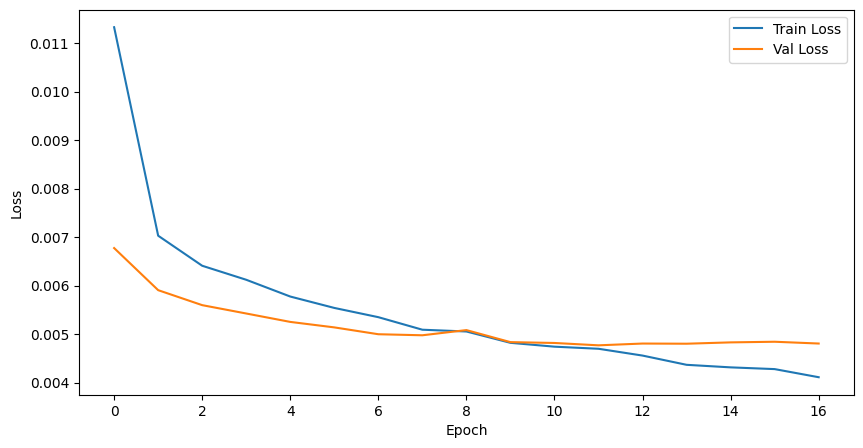

In [65]:
plt.figure(figsize=(10,5))
plt.plot(en2_log['train_losses'], label='Train Loss')
plt.plot(en2_log['test_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

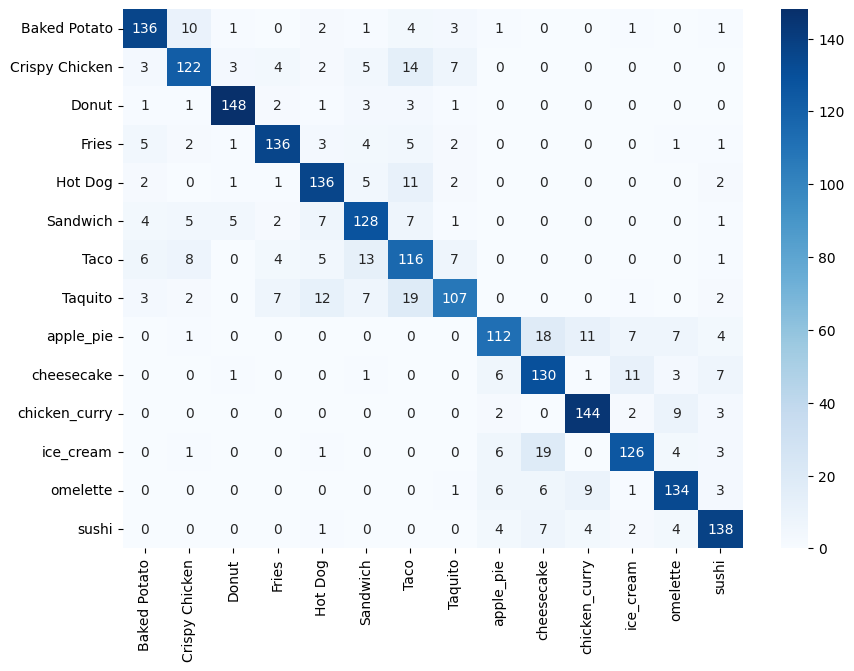

In [43]:
# print confusion matrix
plot_confusion_matrix(en2, valloader, device)

In [44]:
_,  accuracy_en2 = test_epoch(en2, valloader, criterion, device)
accuracy_en2

0.809375

In [45]:
_ , accuracy_test = test_epoch(en2, testloader, criterion, device)
accuracy_test

0.7821428571428571

## Report risultati

In [74]:
from sklearn.metrics import classification_report

en2.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = en2(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ======================================
# SUMMARY AUTOMATICO
# ======================================

report = classification_report(
    all_labels,
    all_preds
)
print(report)

              precision    recall  f1-score   support

           0       0.78      0.75      0.76       200
           1       0.84      0.84      0.84       200
           2       0.90      0.88      0.89       200
           3       0.83      0.88      0.85       200
           4       0.77      0.78      0.77       200
           5       0.73      0.80      0.76       200
           6       0.59      0.60      0.60       200
           7       0.78      0.64      0.70       200
           8       0.75      0.68      0.71       200
           9       0.77      0.83      0.80       200
          10       0.81      0.85      0.83       200
          11       0.81      0.78      0.79       200
          12       0.76      0.81      0.78       200
          13       0.85      0.83      0.84       200

    accuracy                           0.78      2800
   macro avg       0.78      0.78      0.78      2800
weighted avg       0.78      0.78      0.78      2800



In [75]:
display(test_df.sort_values('class_id'))

,class_id,count,class_name
0,0,200,Baked Potato
1,1,200,Crispy Chicken
2,2,200,Donut
3,3,200,Fries
4,4,200,Hot Dog
5,5,200,Sandwich
6,6,200,Taco
7,7,200,Taquito
8,8,200,apple_pie
9,9,200,cheesecake


## ResNet 50

In [29]:
from torchvision.models import resnet50, ResNet50_Weights

In [30]:
rs50 = resnet50(weights = ResNet50_Weights.IMAGENET1K_V1).to(device)

In [31]:
summary(rs50,(3,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           9,408
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]           4,096
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          36,864
       BatchNorm2d-9           [-1, 64, 64, 64]             128
             ReLU-10           [-1, 64, 64, 64]               0
           Conv2d-11          [-1, 256, 64, 64]          16,384
      BatchNorm2d-12          [-1, 256, 64, 64]             512
           Conv2d-13          [-1, 256, 64, 64]          16,384
      BatchNorm2d-14          [-1, 256,

## Congelamento dei pesi convoluzionali

*vogliamo addestrare solo la rete fully connected quindi congeliamo i parametri della rete convoluzionale*

In [32]:
for param in rs50.parameters():
    param.requires_grad = False

In [33]:
rs50.fc.in_features

2048

In [34]:
class RS50Classifier(nn.Module):
    def __init__(self, rs_backbone, input_features, num_classes):
        super().__init__()
        self.features = nn.Sequential(*list(rs_backbone.children())[:-1])
        # istruzione per avere numero di features in input dell fc
        #self.features = rs_backbone.fc.in_features
        # gap eliminato perchè c'è già
        #self.pooling = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Sequential(
    nn.Linear(input_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, num_classes)
)
    def forward(self, x):
        x = self.features(x) #[N, 512, 8, 8]
        #x = self.pooling(x) #[N, 512, 1, 1]
        x = torch.flatten(x, 1) #[N, 512]
        x = self.fc(x) #[N, 14]
        return x

*512 è la dimensione in input per la fully connected mentre 14 sono le classi del nostro dataset*

In [35]:
rs50 = RS50Classifier(rs50, 2048, 14).to(device)

In [36]:
summary(rs50, (3,256,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           9,408
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
         MaxPool2d-4           [-1, 64, 64, 64]               0
            Conv2d-5           [-1, 64, 64, 64]           4,096
       BatchNorm2d-6           [-1, 64, 64, 64]             128
              ReLU-7           [-1, 64, 64, 64]               0
            Conv2d-8           [-1, 64, 64, 64]          36,864
       BatchNorm2d-9           [-1, 64, 64, 64]             128
             ReLU-10           [-1, 64, 64, 64]               0
           Conv2d-11          [-1, 256, 64, 64]          16,384
      BatchNorm2d-12          [-1, 256, 64, 64]             512
           Conv2d-13          [-1, 256, 64, 64]          16,384
      BatchNorm2d-14          [-1, 256,

In [37]:
rs50_save_folder = "models/rs50/"
#os.makedirs(rs50_save_folder, exist_ok = True)
rs50_save_file = os.path.join(rs50_save_folder,"model.pt")
rs50_save_log = os.path.join(rs50_save_folder,"log.json")

## **Impostazione dei parametri per l'addestramento:**

*  Criterion: Crossentropy loss (per problemi di classificazione con N-Classi)
*  Optimizer: Adam (usato nelle reti neurali con molti parametri)
*  Early stopping
*  Epoche: 100


In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rs50.fc.parameters(), lr=0.001)
# Scheduler per ridurre il learning rate se la validation loss non migliora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
early_stopping = EarlyStopping(rs50_save_file, patience=5, min_delta=0)
epochs = 100

## **Addestramento della rete**
*come anticipato si addestra la rete fully connected in quanto gli i parametri strati convoluzionali sono congelati*


In [39]:
train_losses, test_losses, test_accuracies = train(rs50, trainloader, valloader, criterion, optimizer, device, epochs, early_stopping)
to_save_json = {"train_losses":train_losses,
            "test_losses":test_losses,
            "test_accuracies":test_accuracies}
with open(rs50_save_log, 'w') as f:
  json.dump(to_save_json, f)

Epoch 1/100, Train Loss: 0.0120, Validation Loss: 0.0068, Validation Accuracy: 0.7500
Epoch 2/100, Train Loss: 0.0071, Validation Loss: 0.0056, Validation Accuracy: 0.7799
Epoch 3/100, Train Loss: 0.0061, Validation Loss: 0.0051, Validation Accuracy: 0.7835
Epoch 4/100, Train Loss: 0.0059, Validation Loss: 0.0051, Validation Accuracy: 0.7911
Epoch 5/100, Train Loss: 0.0054, Validation Loss: 0.0047, Validation Accuracy: 0.8107
Epoch 6/100, Train Loss: 0.0053, Validation Loss: 0.0047, Validation Accuracy: 0.7946
Epoch 7/100, Train Loss: 0.0051, Validation Loss: 0.0045, Validation Accuracy: 0.8080
Epoch 8/100, Train Loss: 0.0050, Validation Loss: 0.0043, Validation Accuracy: 0.8112
Epoch 9/100, Train Loss: 0.0047, Validation Loss: 0.0042, Validation Accuracy: 0.8174
Epoch 10/100, Train Loss: 0.0048, Validation Loss: 0.0044, Validation Accuracy: 0.8219
Epoch 11/100, Train Loss: 0.0047, Validation Loss: 0.0043, Validation Accuracy: 0.8121
Epoch 12/100, Train Loss: 0.0045, Validation Loss: 0

In [40]:
rs50.load_state_dict(torch.load(rs50_save_file))
with open(rs50_save_log, "r") as f:
    rs50_log = json.load(f)

Test sul dataset di validazione

In [41]:
val_loss, val_accuracy = test_epoch(rs50, valloader, criterion, device)

Il test sull'accuratezza mostra un valore dell'80% che è accettabile anche se non eccellente

## **Plot e confronto per la verifica di overfitting**

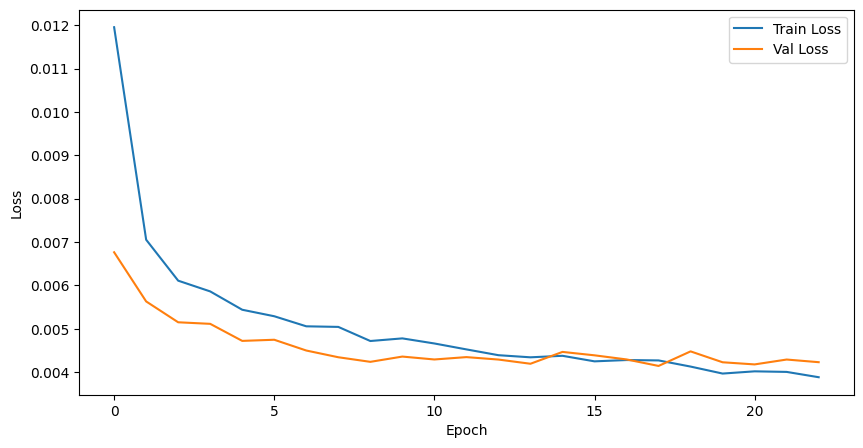

In [42]:
plt.figure(figsize=(10,5))
plt.plot(rs50_log['train_losses'], label='Train Loss')
plt.plot(rs50_log['test_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

## **Matrice di confusione**

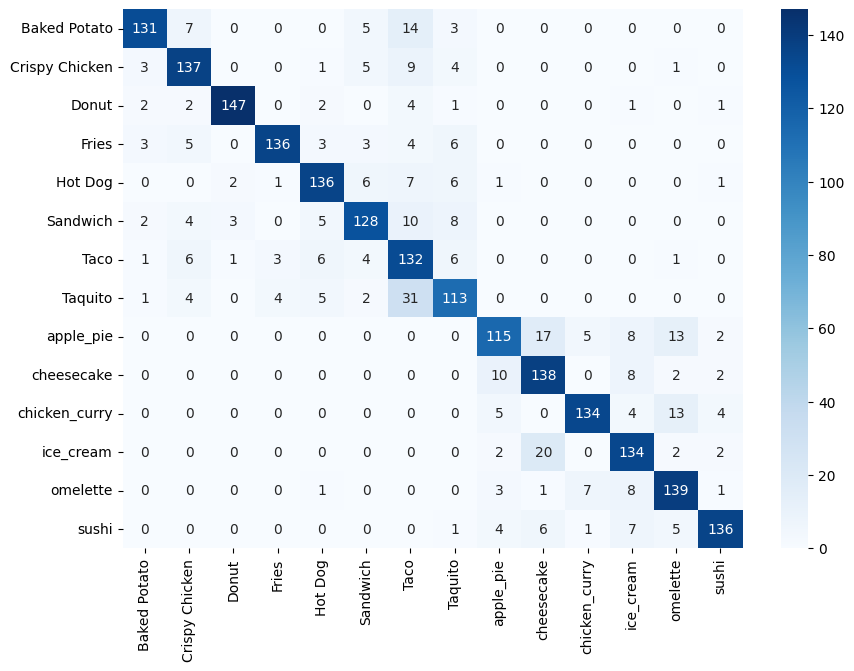

In [43]:
# print confusion matrix
plot_confusion_matrix(rs50, valloader, device)

## Test Finale

In [44]:
_,  accuracy_rs50 = test_epoch(rs50, valloader, criterion, device)
accuracy_rs50


0.8285714285714286

In [45]:
_ , accuracy_test = test_epoch(rs50, testloader, criterion, device)
accuracy_test

0.8260714285714286

## Classification Report ResNet50

In [70]:
from sklearn.metrics import classification_report

rs50.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = rs50(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ======================================
# SUMMARY AUTOMATICO
# ======================================

report = classification_report(
    all_labels,
    all_preds
)

print(report)

              precision    recall  f1-score   support

           0       0.89      0.81      0.85       200
           1       0.86      0.91      0.88       200
           2       0.94      0.93      0.94       200
           3       0.92      0.87      0.89       200
           4       0.83      0.83      0.83       200
           5       0.82      0.80      0.81       200
           6       0.63      0.77      0.69       200
           7       0.82      0.73      0.78       200
           8       0.79      0.71      0.75       200
           9       0.79      0.83      0.81       200
          10       0.89      0.81      0.85       200
          11       0.79      0.86      0.82       200
          12       0.77      0.84      0.80       200
          13       0.91      0.84      0.88       200

    accuracy                           0.83      2800
   macro avg       0.83      0.83      0.83      2800
weighted avg       0.83      0.83      0.83      2800



In [76]:
display(test_df.sort_values('class_id'))

,class_id,count,class_name
0,0,200,Baked Potato
1,1,200,Crispy Chicken
2,2,200,Donut
3,3,200,Fries
4,4,200,Hot Dog
5,5,200,Sandwich
6,6,200,Taco
7,7,200,Taquito
8,8,200,apple_pie
9,9,200,cheesecake


## **Conclusioni**

In riferimento alle singole reti, i risultati in termini di confronto tra val_loss e train_loss mostrano un leggero overfitting e una accuratezza finale dell' 80% non proprio entusiasmante. Tuttavia la matrice di confusione è più confortante in quanto mostra solo un residuo di falsi positivi e falsi negativi accettabili relativamente al campo di applicazione

Invece, il confronto tra le curve di rendimento dei due modelli indica una migliore performance della ResNet50 in termini di overfitting e riduzinoe dell'errore ma con una necessità di un numero superiore di iterazioni. Per converso la rete Efficient Net ha dato un risultato mediamente peggiore in termini di overfitting ma con un risparmio di iterazioni e una percentuale di accuratezza più alta.

Nonostante vi sia una distribuzione omogenea delle occorrenze tra le classi, le classi 2 e 3 "Donat" e "Fries" dimostrano un learning rate più alto.

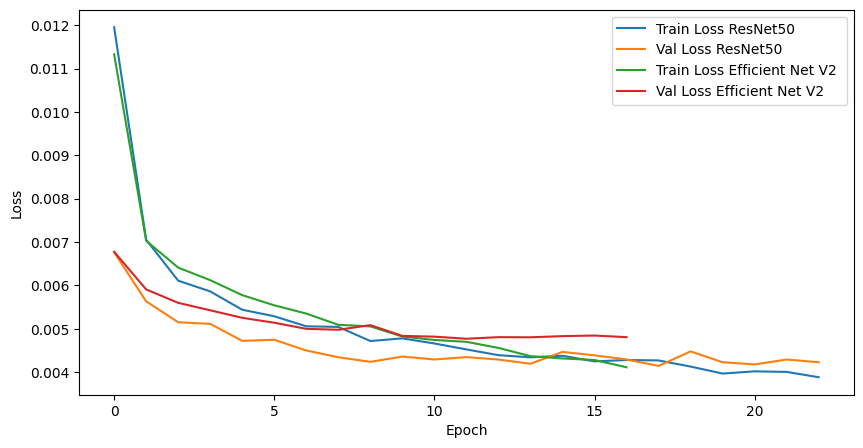

In [66]:
plt.figure(figsize=(10,5))
plt.plot(rs50_log['train_losses'], label='Train Loss ResNet50')
plt.plot(rs50_log['test_losses'], label='Val Loss ResNet50')
plt.plot(en2_log['train_losses'], label='Train Loss Efficient Net V2 ')
plt.plot(en2_log['test_losses'], label='Val Loss Efficient Net V2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
